In [1]:
!pip install -q git+https://github.com/RayenSansa03/aeroguard.git@main --force-reinstall --no-deps

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aeroguard.donnees_ml import preparer_xy

DOSSIER = "/content/drive/MyDrive/aeroguard"
vols = pd.read_parquet(f"{DOSSIER}/data/processed/vols_ncmapss.parquet")

X_train, y_train = preparer_xy(vols, "train")
X_val, y_val = preparer_xy(vols, "val")

print("Train :", X_train.shape, "| Validation :", X_val.shape)
print("Part de vols usés (train) :", round(y_train.mean(), 3))

Mounted at /content/drive
Train : (3716, 126) | Validation : (819, 126)
Part de vols usés (train) : 0.705


In [3]:
def somme_ponderee(entrees, poids, biais):
    """Étape 2 : z = w1*x1 + w2*x2 + ... + b"""
    return np.dot(entrees, poids) + biais


def relu(z):
    """Robinet : 0 si z est négatif, z sinon."""
    return np.maximum(0, z)


def sigmoide(z):
    """Variateur : écrase z entre 0 et 1."""
    return 1 / (1 + np.exp(-z))


def neurone(entrees, poids, biais, activation):
    """Un neurone complet : somme pondérée puis activation."""
    return activation(somme_ponderee(entrees, poids, biais))


# Exemple : T48 et Wf normalisés d'un vol
entrees_exemple = np.array([1.2, 0.8])
poids_exemple = np.array([2.0, 1.0])
biais_exemple = -1.5

z = somme_ponderee(entrees_exemple, poids_exemple, biais_exemple)
print(f"Somme pondérée z = 2.0×1.2 + 1.0×0.8 − 1.5 = {z:.2f}")
print(f"Sortie ReLU      = {relu(z):.3f}")
print(f"Sortie sigmoïde  = {sigmoide(z):.3f}  → probabilité d'usure")

Somme pondérée z = 2.0×1.2 + 1.0×0.8 − 1.5 = 1.70
Sortie ReLU      = 1.700
Sortie sigmoïde  = 0.846  → probabilité d'usure


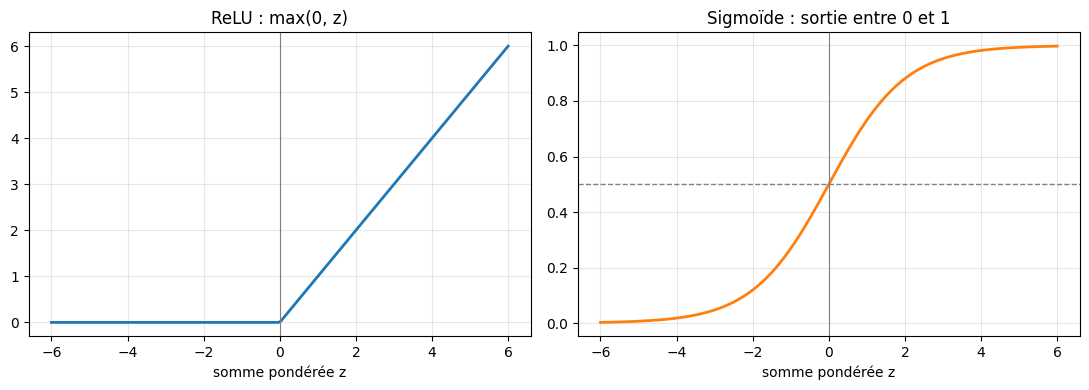

In [4]:
valeurs_z = np.linspace(-6, 6, 200)

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(valeurs_z, relu(valeurs_z), color="tab:blue", linewidth=2)
axes[0].set_title("ReLU : max(0, z)")
axes[1].plot(valeurs_z, sigmoide(valeurs_z), color="tab:orange", linewidth=2)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Sigmoïde : sortie entre 0 et 1")
for axe in axes:
    axe.axvline(0, color="gray", linewidth=0.8)
    axe.set_xlabel("somme pondérée z")
    axe.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
lot_de_vols = np.array([
    [-0.5, -0.3],   # vol plutôt sain
    [1.2, 0.8],     # vol de l'exemple
    [2.5, 1.9],     # vol très chaud
])

probas_lot = neurone(lot_de_vols, poids_exemple, biais_exemple, sigmoide)

print("Forme des entrées :", lot_de_vols.shape, "(vols, capteurs)")
print("Forme des poids   :", poids_exemple.shape, "(capteurs,)")
print("Forme des sorties :", probas_lot.shape, "(vols,)")
print("Probabilités      :", probas_lot.round(3))

Forme des entrées : (3, 2) (vols, capteurs)
Forme des poids   : (2,) (capteurs,)
Forme des sorties : (3,) (vols,)
Probabilités      : [0.057 0.846 0.996]


In [6]:
def choisir_colonne(colonnes, capteur, phase="montee"):
    """Choisit la feature d'un capteur, de préférence pendant la montée."""
    candidates = [c for c in colonnes if c.startswith(f"{capteur}_") and phase in c]
    if not candidates:
        candidates = [c for c in colonnes if c.startswith(f"{capteur}_")]
    return candidates[0] if candidates else None


capteurs_disponibles = sorted({c.split("_")[0] for c in X_train.columns})
print("Capteurs disponibles :", capteurs_disponibles)

colonne_t48 = choisir_colonne(X_train.columns, "T48")
colonne_wf = choisir_colonne(X_train.columns, "Wf") or choisir_colonne(X_train.columns, "T50")
colonnes_neurone = [colonne_t48, colonne_wf]
print("Entrées du neurone :", colonnes_neurone)

# Normalisation avec les statistiques du TRAIN uniquement (pas de fuite)
moyennes = X_train[colonnes_neurone].mean()
ecarts_types = X_train[colonnes_neurone].std()


def normaliser(X):
    return ((X[colonnes_neurone] - moyennes) / ecarts_types).fillna(0).to_numpy()


Xn_train = normaliser(X_train)
Xn_val = normaliser(X_val)
print("Moyenne après normalisation (train) :", Xn_train.mean(axis=0).round(3))
print("Écart-type après normalisation      :", Xn_train.std(axis=0).round(3))

Capteurs disponibles : ['Nc', 'Nf', 'P15', 'P2', 'P21', 'P24', 'P40', 'P50', 'Ps30', 'T24', 'T30', 'T48', 'T50', 'Wf']
Entrées du neurone : ['T48_mean_montee', 'Wf_mean_montee']
Moyenne après normalisation (train) : [0. 0.]
Écart-type après normalisation      : [1. 1.]


In [7]:
from aeroguard.evaluation import appliquer_seuil, metriques

poids_manuels = np.array([1.0, 1.0])
biais_manuel = 0.0

probas_manuelles = neurone(Xn_val, poids_manuels, biais_manuel, sigmoide)
scores_manuels = metriques(y_val, appliquer_seuil(probas_manuelles, 0.5), probas_manuelles)

print(f"F1 macro : {scores_manuels['f1_macro']:.3f}")
print(f"PR-AUC   : {scores_manuels['pr_auc']:.3f}")

F1 macro : 0.656
PR-AUC   : 0.917


In [8]:
essais_de_poids = [
    ([1.0, 0.0], 0.0),
    ([0.0, 1.0], 0.0),
    ([1.0, 1.0], 0.0),
    ([2.0, 1.0], 0.0),
    ([1.0, 1.0], 1.0),
    ([-1.0, -1.0], 0.0),
]

resultats_essais = []
for poids_essai, biais_essai in essais_de_poids:
    probas_essai = neurone(Xn_val, np.array(poids_essai), biais_essai, sigmoide)
    scores_essai = metriques(y_val, appliquer_seuil(probas_essai, 0.5), probas_essai)
    resultats_essais.append({
        "poids": poids_essai,
        "biais": biais_essai,
        "f1_macro": round(scores_essai["f1_macro"], 3),
        "pr_auc": round(scores_essai["pr_auc"], 3),
    })

pd.DataFrame(resultats_essais).sort_values("f1_macro", ascending=False)

,poids,biais,f1_macro,pr_auc
2,"[1.0, 1.0]",0.0,0.656,0.917
3,"[2.0, 1.0]",0.0,0.651,0.932
0,"[1.0, 0.0]",0.0,0.625,0.956
1,"[0.0, 1.0]",0.0,0.604,0.873
4,"[1.0, 1.0]",1.0,0.602,0.917
5,"[-1.0, -1.0]",0.0,0.267,0.602


In [9]:
from sklearn.linear_model import LogisticRegression

regression = LogisticRegression().fit(Xn_train, y_train)
poids_appris = regression.coef_[0]
biais_appris = regression.intercept_[0]

probas_neurone = neurone(Xn_val, poids_appris, biais_appris, sigmoide)
probas_sklearn = regression.predict_proba(Xn_val)[:, 1]

assert np.allclose(probas_neurone, probas_sklearn), "Les deux devraient être identiques"
print("✅ Notre neurone et la régression logistique donnent EXACTEMENT les mêmes probabilités")

print(f"Poids appris : {colonnes_neurone[0]} = {poids_appris[0]:.3f}, "
      f"{colonnes_neurone[1]} = {poids_appris[1]:.3f}")
print(f"Biais appris : {biais_appris:.3f}")

scores_appris = metriques(y_val, appliquer_seuil(probas_neurone, 0.5), probas_neurone)
print(f"F1 macro : {scores_appris['f1_macro']:.3f} | PR-AUC : {scores_appris['pr_auc']:.3f}")

✅ Notre neurone et la régression logistique donnent EXACTEMENT les mêmes probabilités
Poids appris : T48_mean_montee = 8.556, Wf_mean_montee = -3.131
Biais appris : 3.837
F1 macro : 0.755 | PR-AUC : 0.955


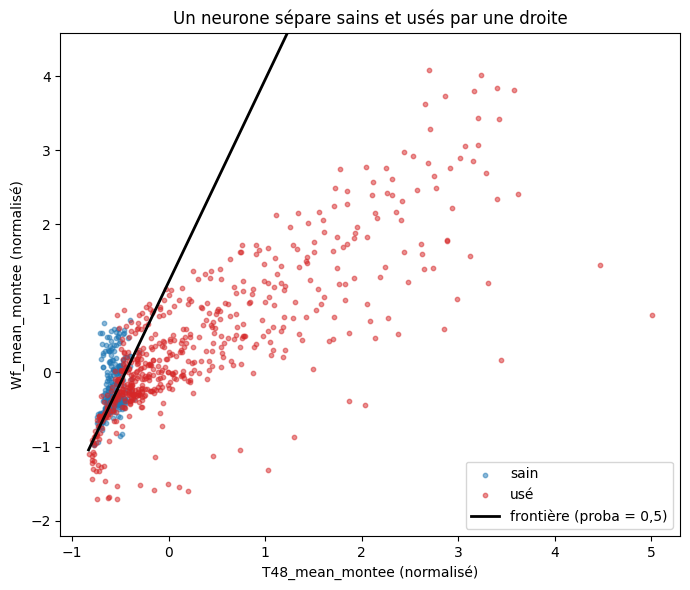

In [10]:
figure, axe = plt.subplots(figsize=(7, 6))
for classe, couleur, nom in [(0, "tab:blue", "sain"), (1, "tab:red", "usé")]:
    masque = (y_val == classe).to_numpy()
    axe.scatter(Xn_val[masque, 0], Xn_val[masque, 1], s=10, alpha=0.5, color=couleur, label=nom)

# Frontière : w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
x1_ligne = np.linspace(Xn_val[:, 0].min(), Xn_val[:, 0].max(), 100)
x2_ligne = -(poids_appris[0] * x1_ligne + biais_appris) / poids_appris[1]
axe.plot(x1_ligne, x2_ligne, color="black", linewidth=2, label="frontière (proba = 0,5)")

axe.set_xlabel(f"{colonnes_neurone[0]} (normalisé)")
axe.set_ylabel(f"{colonnes_neurone[1]} (normalisé)")
axe.set_ylim(Xn_val[:, 1].min() - 0.5, Xn_val[:, 1].max() + 0.5)
axe.set_title("Un neurone sépare sains et usés par une droite")
axe.legend()
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/41_frontiere_neurone.png", dpi=150)
plt.show()